<a href="https://colab.research.google.com/github/Suvanga/ML_DL/blob/main/Solution_Exercise_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. PyTorch Workflow Exercise Template

The following is a template for the PyTorch workflow exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [21]:
# Import necessary libraries
import torch
import matplotlib.pyplot as plt
from torch import nn
from pathlib import Path
import numpy as np
import pandas as pd

In [22]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Create a straight line dataset using the linear regression formula (`weight * X + bias`).
  * Set `weight=0.3` and `bias=0.9` there should be at least 100 datapoints total.
  * Split the data into 80% training, 20% testing.
  * Plot the training and testing data so it becomes visual.

Your output of the below cell should look something like:
```
Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900])
y: tensor([0.9000, 0.9030, 0.9060, 0.9090, 0.9120, 0.9150, 0.9180, 0.9210, 0.9240,
        0.9270])
```

Of course the numbers in `X` and `y` may be different but ideally they're created using the linear regression formula.

In [23]:
# Create the data parameters
X = torch.range(0, 1, 0.01).unsqueeze(dim=1)
y = 0.3 * X + 0.9

# Make X and y using linear regression feature


print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\ny: {y[:10]}")

Number of X samples: 101
Number of y samples: 101
First 10 X & y samples:
X: tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])
y: tensor([[0.9000],
        [0.9030],
        [0.9060],
        [0.9090],
        [0.9120],
        [0.9150],
        [0.9180],
        [0.9210],
        [0.9240],
        [0.9270]])


/tmp/ipython-input-474817264.py:2: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  X = torch.range(0, 1, 0.01).unsqueeze(dim=1)


In [24]:
# Split the data into training and testing
split_data = 0.8
split_index = int(split_data * len(X))
X_train, y_train = X[:split_index], y[:split_index]
X_test, y_test = X[split_index:], y[split_index:]

In [25]:
# Plot the training and testing data

def plot_predictions( predictions):
  plt.figure(figsize=(10, 7))
  plt.scatter(X_test, y_test, c="b", s=4, label="Testing data")
  plt.scatter(X_train, y_train, c="g", s=4, label="Training data")
  plt.legend()
  if predictions is not None:
      plt.scatter(X_test, predictions, c="r", s=4, label="Predictions")

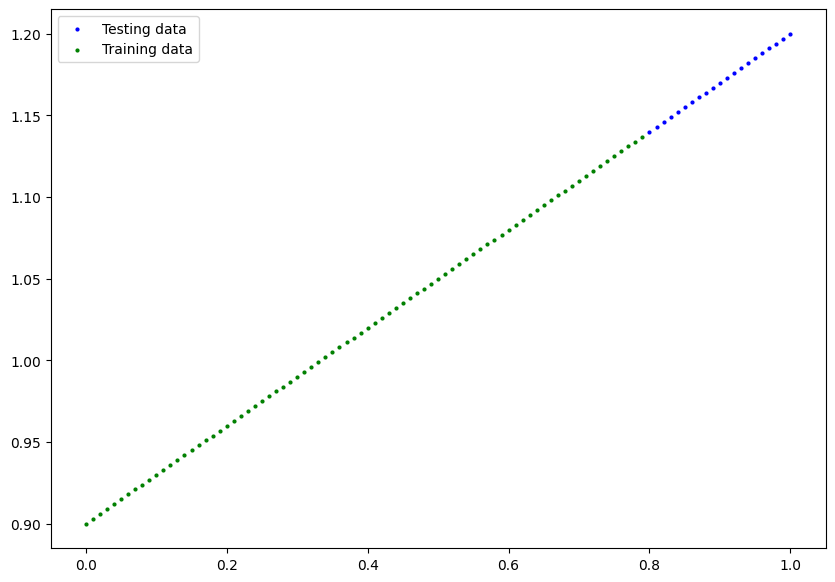

In [26]:
plot_predictions(None)

## 2. Build a PyTorch model by subclassing `nn.Module`.
  * Inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`.
  * Implement the `forward()` method to compute the linear regression function you used to create the dataset in 1.
  * Once you've constructed the model, make an instance of it and check its `state_dict()`.
  * **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter()` you can.

In [42]:
# Create PyTorch linear regression model by subclassing nn.Module
class LinearRegressionModel(nn.Module):
    def __init__(self):
      super().__init__()
      self.Linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.Linear(x)

In [43]:
# Instantiate the model and put it to the target device
model_0 = LinearRegressionModel()
model_0.state_dict()

OrderedDict([('Linear.weight', tensor([[0.7645]])),
             ('Linear.bias', tensor([0.8300]))])

## 3. Create a loss function and optimizer using `nn.L1Loss()` and `torch.optim.SGD(params, lr)` respectively.
  * Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
  * Write a training loop to perform the appropriate training steps for 300 epochs.
  * The training loop should test the model on the test dataset every 20 epochs.

In [44]:
# Create the loss function and optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)
loss_fn = nn.L1Loss()

In [45]:
torch.manual_seed(42)
from numpy.matrixlib import test




epochs =200

#tracking experiments
epoch_count = []
loss_values = []
test_loss_values= []

##Training Mode
for epoch in range(epochs):
    model_0.train()
    pred_y = model_0(X_train)
    # loss_fn  = torch.nn.L1Loss()
    loss = loss_fn(pred_y, y_train)
    # optimizer = torch.optim.SGD(params=model_0.parameters(), lr = 0.01)
    optimizer.zero_grad()
    loss.backward() #Loss calculation
    optimizer.step() #Gradient descent

  ##Testing mode :
    model_0.eval()
    with torch.inference_mode():
      # Do the forward pass
      test_pred = model_0(X_test)
      #calculate the loss
      test_loss = loss_fn(test_pred,y_test)
    #prinitng out the test resukts
      if epoch%10 ==0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Loss:{loss} | Test_Loss: {test_loss} ")

      print(model_0.state_dict())


Epoch: 0 | Loss:0.1275613009929657 | Test_Loss: 0.3388076424598694 
OrderedDict({'Linear.weight': tensor([[0.7609]]), 'Linear.bias': tensor([0.8240])})
OrderedDict({'Linear.weight': tensor([[0.7573]]), 'Linear.bias': tensor([0.8183])})
OrderedDict({'Linear.weight': tensor([[0.7537]]), 'Linear.bias': tensor([0.8128])})
OrderedDict({'Linear.weight': tensor([[0.7502]]), 'Linear.bias': tensor([0.8078])})
OrderedDict({'Linear.weight': tensor([[0.7468]]), 'Linear.bias': tensor([0.8030])})
OrderedDict({'Linear.weight': tensor([[0.7434]]), 'Linear.bias': tensor([0.7985])})
OrderedDict({'Linear.weight': tensor([[0.7401]]), 'Linear.bias': tensor([0.7943])})
OrderedDict({'Linear.weight': tensor([[0.7369]]), 'Linear.bias': tensor([0.7905])})
OrderedDict({'Linear.weight': tensor([[0.7338]]), 'Linear.bias': tensor([0.7870])})
OrderedDict({'Linear.weight': tensor([[0.7307]]), 'Linear.bias': tensor([0.7838])})
Epoch: 10 | Loss:0.0945572778582573 | Test_Loss: 0.2653825581073761 
OrderedDict({'Linear.we

## 4. Make predictions with the trained model on the test data.
  * Visualize these predictions against the original training and testing data (**note:** you may need to make sure the predictions are *not* on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

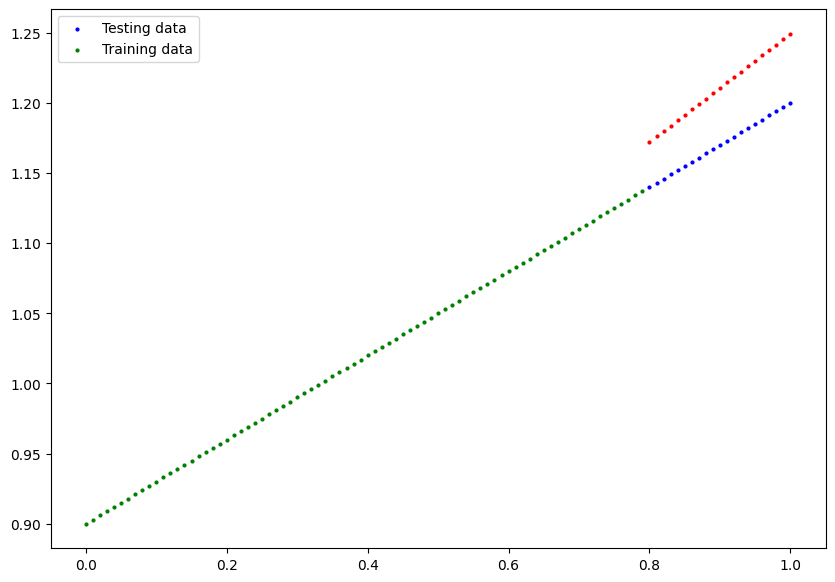

In [46]:
# Make predictions with the model
# OrderedDict({'weights': tensor([0.3484]), 'bias': tensor([0.1588])})
plot_predictions(predictions = test_pred)


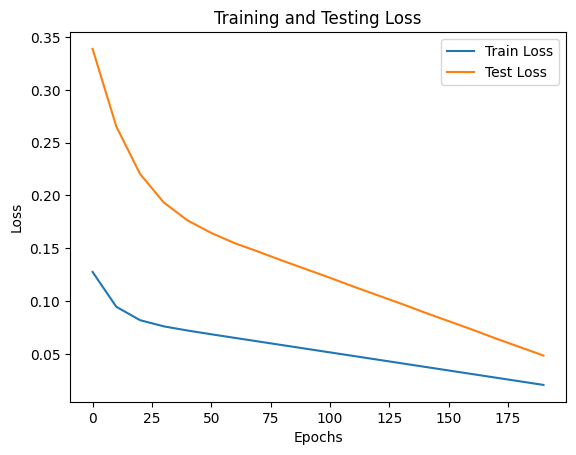

In [47]:
# Plot the predictions (these may need to be on a specific device)
# plotting the loss curves
with torch.inference_mode():

  plt.plot(epoch_count, loss_values, label = "Train Loss")
  plt.plot(epoch_count, test_loss_values, label = "Test Loss")
  plt.title("Training and Testing Loss")
  plt.ylabel("Loss")
  plt.xlabel("Epochs")
  plt.legend()

## 5. Save your trained model's `state_dict()` to file.
  * Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
  * Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [52]:
from pathlib import Path

#MAKING THE MODEL directory
Model_Path = Path("Models")
Model_Path.mkdir(parents=True, exist_ok=True)

# creating model path
Model_Name = "model_0.pth"
model_Save_Path = Model_Path / Model_Name



#saving ther model with state_dict
torch.save(model_0.state_dict(), model_Save_Path)

In [55]:
# Create new instance of model and load saved state dict (make sure to put it on the target device)
loaded = LinearRegressionModel()
loaded.load_state_dict(torch.load(f= model_Save_Path, weights_only=True))


<All keys matched successfully>

In [59]:
# Make predictions with loaded model and compare them to the previous
loaded.eval()
with torch.inference_mode():
  loaded_model_preds =loaded(X_test)

loaded_model_preds

model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds
y_preds == loaded_model_preds


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])